# Data and model testing

In [1]:
import os

# gets rid of irritating warnings
os.environ["TOKENIZERS_PARALLELISM"] = "false"

## Data preprocessing and initial quality checking

We will be using [booking.com reviews dataset](https://www.kaggle.com/datasets/jiashenliu/515k-hotel-reviews-data-in-europe?resource=download), with over 500 thousand reviews of hotels. They are either positive or negative, and we will focus on review sentiment. We have [hosted it on HuggingFace](https://huggingface.co/datasets/morgul10/booking_reviews), with just the relevant columns.

We will start with loading the data and initial checks - a **smoke test** of the data. Aim is to understand our dataset, and to detect obvious and serious problems. It is always a necessary process in ML.

Most basic checks, which should always be performed, are:
- data length
- column types
- example rows
- exact duplicates check
- labels distributions (for supervised problems)
- more specific checks depending on the modality, e.g. text lengths distribution in NLP

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from datasets import load_dataset


df_raw = load_dataset("morgul10/booking_reviews")["train"].to_pandas()
df_neg = df_raw["Negative_Review"].str.strip()
df_pos = df_raw["Positive_Review"].str.strip()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


In [3]:
print("Total data length:", len(df_raw))
print("Negative reviews:", len(df_neg))
print("Positive reviews:", len(df_pos))

Total data length: 515738
Negative reviews: 515738
Positive reviews: 515738


In [4]:
print("Data types:")
display(df_raw.dtypes)

Data types:


,0
Negative_Review,object
Positive_Review,object


In [5]:
print("First rows:")
display(df_raw.head(10))

First rows:


,Negative_Review,Positive_Review
0,I am so angry that i made this post available...,Only the park outside of the hotel was beauti...
1,No Negative,No real complaints the hotel was great great ...
2,Rooms are nice but for elderly a bit difficul...,Location was good and staff were ok It is cut...
3,My room was dirty and I was afraid to walk ba...,Great location in nice surroundings the bar a...
4,You When I booked with your company on line y...,Amazing location and building Romantic setting
5,Backyard of the hotel is total mess shouldn t...,Good restaurant with modern design great chil...
6,Cleaner did not change our sheet and duvet ev...,The room is spacious and bright The hotel is ...
7,Apart from the price for the brekfast Everyth...,Good location Set in a lovely park friendly s...
8,Even though the pictures show very clean room...,No Positive
9,The aircondition makes so much noise and its ...,The room was big enough and the bed is good T...


In [6]:
print("Last rows:")
display(df_raw.tail(10))

Last rows:


,Negative_Review,Positive_Review
515728,Everything,Nothing
515729,No Negative,The breakfast was excelent lots of fress frui...
515730,no free parking the room was in another build...,large room
515731,No parking Public parking garage is 15 Euro p...,Good breakfast
515732,No Negative,helpful staff allowed me to check in early as...
515733,no trolly or staff to help you take the lugga...,location
515734,The hotel looks like 3 but surely not 4,Breakfast was ok and we got earlier check in
515735,The ac was useless It was a hot week in vienn...,No Positive
515736,No Negative,The rooms are enormous and really comfortable...
515737,I was in 3rd floor It didn t work Free Wife,staff was very kind


<Axes: title={'center': 'Negative reviews lengths'}, ylabel='Frequency'>

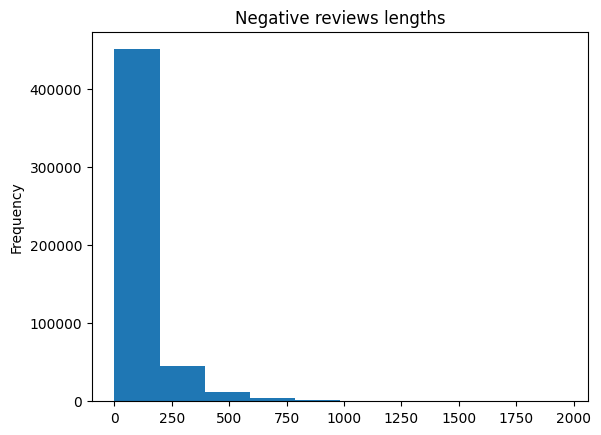

In [7]:
df_neg.str.len().plot.hist(title="Negative reviews lengths")

<Axes: title={'center': 'Positive reviews lengths'}, ylabel='Frequency'>

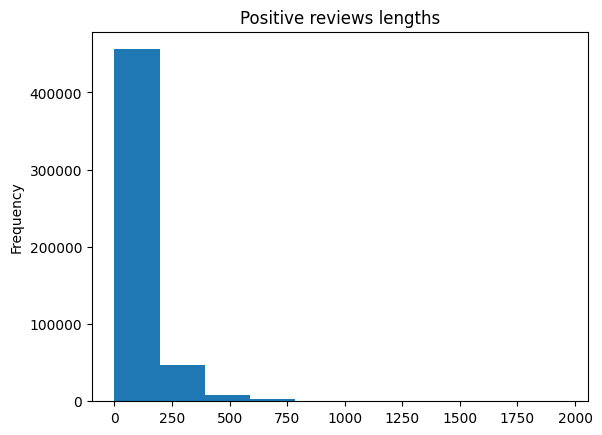

In [8]:
df_pos.str.len().plot.hist(title="Positive reviews lengths")

As you can see, the data contains quite a few "No Negatives" and "No Positive" rows. This is a widespread problem with "empty" rows, which are not really empty. They can take a form of:
- default text, like we have here (frequent in automated forms, data from web scraping etc.)
- empty string instead of NULL
- deleted rows, but only marked with "deleted" column (frequent in data warehouses)

Those problems can also crop up during inference (e.g., empty text), and should be handled properly.

This is a particular instance of **duplicate data** problem, which is surprisingly common. Another reason may be that people writing texts don't care, e.g. input generic answers like "ok" or "everything". This biases the model, essentially putting more weights on those texts. Worse, they can have different labels, which introduces strong noise.

Let's see how frequent is this problem.

### Exercise 1 (1 point)

Check the percentage of 20 most common text duplicates. This can be achieved with Pandas code conceptually similar to a combination of GROUP BY and COUNT aggregation. Check it:
- in positive and negative subsets
- for the whole dataset

### Positive duples counts

In [9]:
#positive series duples
df_pos.groupby(by=df_pos).count().sort_values(ascending=False).head(20)


,Positive_Review
Positive_Review,
No Positive,35946
Location,10137
Everything,2897
location,1736
Nothing,1468
Great location,1419
The location,1341
Good location,1203
Breakfast,664


In [10]:
#positive duplicates coverage for top 20 duples
supercount = df_pos.groupby(by=df_pos).count().sort_values(ascending=False).head(20).sum()
supercount
totalcount = df_pos.count()
print("Positive reviewstop 20 duples: ", supercount, "total: ", totalcount, "percentage: ", supercount / totalcount)

Positive reviewstop 20 duples:  60783 total:  515738 percentage:  0.11785635341975964


### Negative duples counts

In [11]:
df_neg.groupby(by=df_neg).count().sort_values(ascending=False).head(20)

,Negative_Review
Negative_Review,
No Negative,127890
Nothing,18531
nothing,2508
None,1166
N A,1060
,849
Nothing really,570
N a,520
All good,470


In [12]:
#negative duplicates coverage for top 20 duples
supercount = df_neg.groupby(by=df_neg).count().sort_values(ascending=False).head(20).sum()
supercount
totalcount = df_neg.count()
print(supercount)
print("Negative reviews top 20 duples: ", supercount, "total: ", totalcount, "percentage: ", supercount / totalcount)

157595
Negative reviews top 20 duples:  157595 total:  515738 percentage:  0.3055718213511512


### Total duples counts in unpivoted data

In [13]:
#unpivoting dataframe for total counting 
pd_melted = pd.melt(
    df_raw,
    value_vars=["Negative_Review", "Positive_Review"],
    var_name="Review_Type",
    value_name="Review_Text",
)
pd_melted

,Review_Type,Review_Text
0,Negative_Review,I am so angry that i made this post available...
1,Negative_Review,No Negative
2,Negative_Review,Rooms are nice but for elderly a bit difficul...
3,Negative_Review,My room was dirty and I was afraid to walk ba...
4,Negative_Review,You When I booked with your company on line y...
...,...,...
1031471,Positive_Review,location
1031472,Positive_Review,Breakfast was ok and we got earlier check in
1031473,Positive_Review,No Positive
1031474,Positive_Review,The rooms are enormous and really comfortable...


In [14]:
#total duplicates coverage for top 20 duples
sdf = pd_melted[["Review_Text"]]["Review_Text"]

# supercount
# totalcount = pd_melted.count()
# print("Total reviews top 20 duples: ", supercount, "total: ", totalcount, "percentage: ", supercount / totalcount)\
print(sdf.groupby(by=sdf).count().sort_values(ascending=False).head(20))
totalduple = sdf.groupby(by=sdf).count().sort_values(ascending=False).head(20).sum()
totalcount = sdf.count()
print("Total reviews top 20 duples: ", totalduple, "total: ", totalcount, "percentage: ", totalduple / totalcount) 

Review_Text
No Negative        127890
No Positive         35946
 Nothing            15538
 Location            9590
 Nothing             4461
 Everything          2610
 nothing             2442
 location            1754
 The location        1171
 N A                 1070
 Great location      1052
                     1032
 Breakfast           1015
 None                1012
 Location             968
 Good location        932
 Everything           654
 Staff                583
 N a                  524
 Friendly staff       518
Name: Review_Text, dtype: int64
Total reviews top 20 duples:  210762 total:  1031476 percentage:  0.20433049339005463


### Manual data cleaning

Imagine training (and testing!) a model on data, where about 25% of negative class is duplicated, or has useless values like "none". Not a good idea, so we will remove those duplicates simply by using a case-insensitive regular expression. We will also remove words like "breakfast" or "location," which do not discriminate at all between positive and negative sentiment.

In [15]:
to_remove = [
    "No Negative", "No Positive", "nothing", "nothing really", "none", "n a", "na",
    "everything", "location", "the location", "breakfast", "the breakfast", "staff",
]
to_remove = [f"^{word}$" for word in to_remove]
to_remove = "|".join(to_remove)
to_remove

'^No Negative$|^No Positive$|^nothing$|^nothing really$|^none$|^n a$|^na$|^everything$|^location$|^the location$|^breakfast$|^the breakfast$|^staff$'

We will also perform two common cleaning steps: deduplication and removing empty strings. We can safely assume that people are lazy and write short, generic reviews, so there will be quite a few duplicates even after removing the most obvious cases.

In [16]:
df_neg_filtered = df_neg[~df_neg.str.contains(to_remove, case=False, na=True, regex=True)]
df_pos_filtered = df_pos[~df_pos.str.contains(to_remove, case=False, na=True, regex=True)]

# empty strings removal
df_neg_filtered = df_neg_filtered[df_neg_filtered.str.len() > 0]
df_pos_filtered = df_pos_filtered[df_pos_filtered.str.len() > 0]

df_neg_filtered = df_neg_filtered.reset_index(drop=True)
df_pos_filtered = df_pos_filtered.reset_index(drop=True)

df_neg_filtered = df_neg_filtered.to_frame().rename(columns={"Negative_Review": "text"})
df_pos_filtered = df_pos_filtered.to_frame().rename(columns={"Positive_Review": "text"})

df_neg_filtered["label"] = 0
df_pos_filtered["label"] = 1

print("Negative samples after filtering:", len(df_neg_filtered))
print("Positive samples after filtering:", len(df_pos_filtered))

df_all = pd.concat([df_neg_filtered, df_pos_filtered], ignore_index=True)
df_all = df_all.drop_duplicates(ignore_index=True)

Negative samples after filtering: 359750
Positive samples after filtering: 459388


Lastly, we have quite a lot of data, so we'll randomly subsample it. We will use stratification, so that the label distribution will be the same after sampling.

**Modify this** depending on your hardware. Very good GPU should handle up to ~100k samples, medium-grade GPU about ~10-50k, and CPU about 5k. The more samples you process, the better the results will be.

In [17]:
df_all[df_all["text"].str.strip().str.contains("The staff were very friendly and helpful", case=False, na=False)]["text"].values

array(['The plates from the plate warmer were cold So the breakfast became cold very quickly But the staff were very friendly and helpful',
       'The wifi tends to get disconnected from time to time The staff were very friendly and helpful but they d open the entrance door without asking sometimes The only window without a curtain was weirdly enough the bathroom window We had to turn off the lights when using it at night',
       'Some of the staff were very friendly and helpful but sadly some were a little stern and unwelcoming',
       'We had a room on the 6th floor at the urban wing facing the Centraal Station view was great except that the windows are not noise proof so there will still be a little bit of noise from the traffic just outside especially if you are a light sleeper Apparently some renovations for the urban wing were still going on above us and we experienced some drilling and knocking noise in the mornings when we were there Otherwise the staff were very friendly an

In [18]:
from sklearn.utils import resample


df = resample(df_all, replace=False, n_samples=50000, random_state=500, stratify=df_all["label"])
df = df.reset_index(drop=True)
df

,text,label
0,Staff was outstanding and very helpful,1
1,Although rooms were modern they were tiny If y...,0
2,Brand new clean hotel with great staff,1
3,The bed was very comfortable Room was quite bi...,1
4,Location and rooftop views excellent,1
...,...,...
49995,City Hotel nice area close to 3 metro stations...,1
49996,There was no external noise granted but the no...,0
49997,iPad controlled room was super cool,1
49998,Young not smiling staff Your receptionist like...,0


## CleanLab blackbox testing

[CleanLab library](https://github.com/cleanlab/cleanlab) aims to provide a blackbox, dead simple to use solution to ensure data quality. It can clean both data and labels, and works for any models. It is based on the framework of **confident learning (CL)**, originally created for detecting problems with data annotations.

The main idea is as follows. A reasonably good model trained on the data should be very confident about properly annotated texts, and uncertain about ambiguous or incorrectly annotated texts. This is measured by predicted class probabilities. There are, of course, more details (e.g., class-conditioning, distinguishing model and data errors), but the general idea is really simple, and works with any data modality. It can not only detect errors, but also fix them. If another label is predicted with very high confidence, there is a high chance it's the correct one.

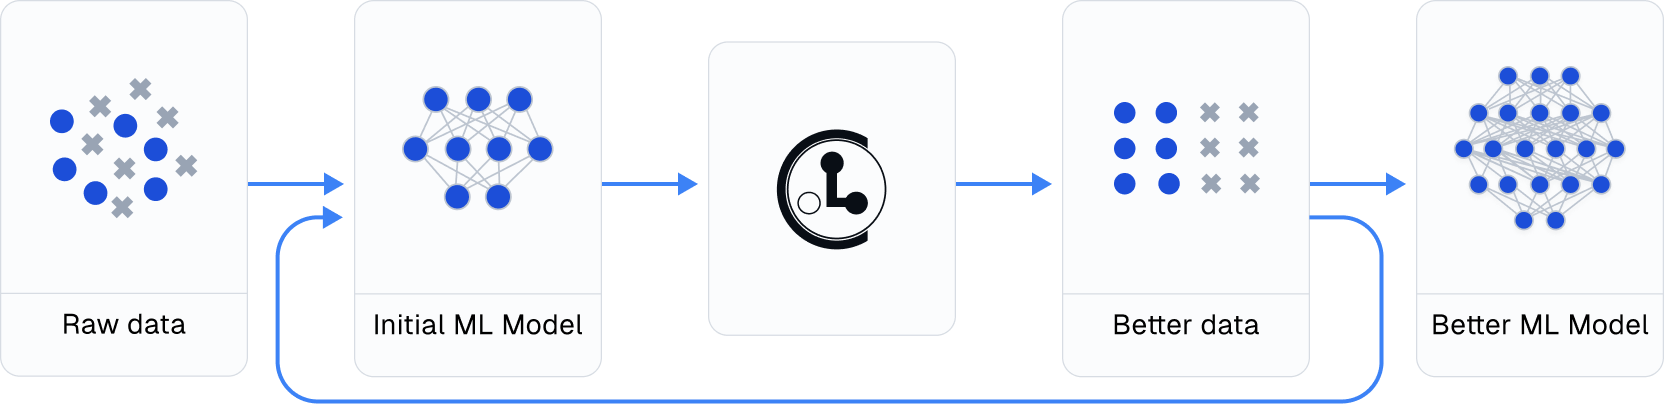

Researchers in confidence learning, and creators of CleanLab, used this methodology in paper ["Pervasive label errors in test sets destabilize machine learning benchmarks" C.G. Northcutt et al](https://arxiv.org/abs/2103.14749). They showed that in popular text and image benchmarking datasets, up to 10% of labels are incorrect.

We will take a similar approach to test our dataset. To avoid a chicken-and-egg problem (we don't have a model yet, but we need model probabilities), we need the **initial model**. A simple, yet effective approach is using a pretrained embedding model, combined with a linear classifier. This method is equivalent to freezing weights and training just the classifier head. Both embeddings and probability predictions are then used by CleanLab to detect problems.

For text classification, the workflow recommended by [HuggingFace Open-Source AI Cookbook](https://huggingface.co/learn/cookbook/en/issues_in_text_dataset) is:
1. Compute text embeddings with a pretrained Sentence Transformer for feature extraction
2. Train logistic regression with cross-validation
3. Gather predicted probabilities (model confidence scores) for validation sets
4. Use CleanLab using this data

Bonus: we originally detected some problems with duplicates in this dataset also by using CleanLab.

### Exercise 2 (1 point)

Implement the `get_initial_model_data()` function:
1. Compute text embeddings with [sentence-transformers](https://sbert.net/docs/sentence_transformer/pretrained_models.html) and `all-MiniLM-L6-v2` model.
2. Create `LogisticRegression` object
3. Train logistic regression and get probability predictions using `cross_val_predict()`. Note that it requires explicitly specifying that `predict_proba()` method should be used, in order to return probabilities, rather than 0/1 labels.


In [19]:
import joblib
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict


def get_initial_model_data(texts: np.ndarray, labels: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    model = SentenceTransformer("all-MiniLM-L6-v2")
    embeddings = model.encode(texts.tolist(), show_progress_bar=True)
    clf = LogisticRegression(max_iter=1000)
    pred_probs = cross_val_predict(clf, embeddings, labels, method="predict_proba")
    return embeddings, pred_probs

#### Verification

In [20]:
texts = df["text"].values
labels = df["label"].values

embeddings, pred_probs = get_initial_model_data(texts, labels)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1563 [00:00<?, ?it/s]

And now, we can use the CleanLab with the obtained embeddings and probability predictions.

In [21]:
texts.shape, labels.shape, embeddings.shape, pred_probs.shape

((50000,), (50000,), (50000, 384), (50000, 2))

In [22]:
#running on collab so installing cleanlab
try:
    from cleanlab import Datalab
except ModuleNotFoundError:
    !pip install cleanlab
    from cleanlab import Datalab


data_dict = {"texts": texts, "labels": labels}
lab = Datalab(data_dict, label_name="labels", task="classification")
lab.find_issues(pred_probs=pred_probs, features=embeddings)
lab.report()

Finding null issues ...
Finding label issues ...
Finding outlier issues ...
Finding near_duplicate issues ...
Finding non_iid issues ...
Finding class_imbalance issues ...
Finding underperforming_group issues ...

Audit complete. 1993 issues found in the dataset.
Dataset Information: num_examples: 50000, num_classes: 2

Here is a summary of various issues found in your data:

    issue_type  num_issues
         label        1101
near_duplicate         590
       outlier         302

Learn about each issue: https://docs.cleanlab.ai/stable/cleanlab/datalab/guide/issue_type_description.html
See which examples in your dataset exhibit each issue via: `datalab.get_issues(<ISSUE_NAME>)`

Data indices corresponding to top examples of each issue are shown below.


----------------------- label issues -----------------------

About this issue:
	Examples whose given label is estimated to be potentially incorrect
    (e.g. due to annotation error) are flagged as having label issues.
    

Number o

About 1.9% of duplicates, even after our cleaning, are quite expected. Many people don't really care and write short, generic reviews. Still, the data-driven approach confirms it, and we'll take a closer look at this. Additionally, about 2.2% of mislabeled data looks quite problematic.

To programmatically inspect a given issue, `.get_issues()` method is used. For a given issue type (see report above for exact names), it returns a DataFrame with score for each sample. Lower score means higher risk of problems. It also returns a column with a boolean indicator whether a given sample has the problem, e.g. `is_near_duplicate_issue` or `is_label_issue`, which uses a default threshold for the score.

Let's inspect the duplicate issues for now.

In [23]:
duplicate_issues = lab.get_issues("near_duplicate")
duplicate_issues = duplicate_issues[duplicate_issues["is_near_duplicate_issue"]]
duplicate_issues = duplicate_issues.sort_values(by="near_duplicate_score")

In [24]:
duplicate_issues

,is_near_duplicate_issue,near_duplicate_score,near_duplicate_sets,distance_to_nearest_neighbor
32780,True,0.000000,[24712],0.000000
16929,True,0.000000,[15056],0.000000
15285,True,0.000000,[27481],0.000000
15056,True,0.000000,[16929],0.000000
14745,True,0.000000,[20555],0.000000
...,...,...,...,...
32049,True,0.121413,[23096],0.028324
23096,True,0.121413,[32049],0.028324
47173,True,0.121616,"[2282, 22843]",0.028375
452,True,0.121707,[43148],0.028398


Row index indicates the row with a problem, and `near_duplicate_sets` are indices of duplicate rows. `distance_to_nearest_neighbor` measures distance between embeddings. Let's see the top 10 cases with most obvious duplicates.

In [25]:
for idx, row in duplicate_issues.head(10).iterrows():
    text = texts[idx]
    neighbors = texts[row["near_duplicate_sets"][:3]]
    print(f"Text: {text}")
    print(f"\tDuplicates: {neighbors}")
    print()

Text: service breakfast
	Duplicates: ['Service breakfast']

Text: Excellent Location to Wembley Stadium
	Duplicates: ['Excellent location to Wembley stadium']

Text: Close to train station and city center
	Duplicates: ['close to train station and city center']

Text: Excellent location to Wembley stadium
	Duplicates: ['Excellent Location to Wembley Stadium']

Text: location and bar area
	Duplicates: ['Location and Bar area']

Text: Everything was Perfect
	Duplicates: ['Everything was perfect' 'Everything were perfect']

Text: Location helpful staff breakfast
	Duplicates: ['Location Helpful staff Breakfast'
 'Location helpful staff good breakfast']

Text: Great Location Great Staff
	Duplicates: ['Great location Great Staff' 'great staff great location'
 'great location good staff']

Text: No comments
	Duplicates: ['NO COMMENTS']

Text: wifi is slow
	Duplicates: ['Wifi is slow' 'WIFI is very slow']



Yeah, we forgot that `Pandas` is case-sensitive about finding duplicates. So with CleanLab, we identified a problem with our preprocessing. We will filter this in just a bit. Let's also see the last 10 duplicates.

In [26]:
for idx, row in duplicate_issues.tail(10).iterrows():
    text = texts[idx]
    neighbors = texts[row["near_duplicate_sets"][:3]]
    print(f"Text: {text}")
    print(f"\tDuplicates: {neighbors}")
    print()

Text: Great location and hotel
	Duplicates: ['great hotel and location']

Text: The location the breakfast
	Duplicates: ['Breakfast and the location']

Text: Breakfast and the location
	Duplicates: ['The location the breakfast']

Text: Staff were very friendly and the hotel was lovely and very clean and comfortable
	Duplicates: ['The staff were very friendly and the hotel was very nice The rooms were very clean and comfortable']

Text: The staff were very friendly and the hotel was very nice The rooms were very clean and comfortable
	Duplicates: ['Staff were very friendly and the hotel was lovely and very clean and comfortable']

Text: Great location and the staff Was very friendly
	Duplicates: ['Great location and staff were friendly']

Text: Great location and staff were friendly
	Duplicates: ['Great location and the staff Was very friendly']

Text: Nothing I can really think of
	Duplicates: ['Nothing I can think of' 'Nothing I can think of']

Text: helpful staff lovely breakfast
	Du

Definitely similar, but not exactly duplicates. We will remove the case-insensitive duplicates now. Note that we will keep the index to avoid recalculation for inspecting further issues.

In [27]:
df["text_lower"] = df["text"].str.lower()
df_deduplicated = df.drop_duplicates(subset="text_lower")
df_deduplicated = df_deduplicated.drop(columns="text_lower")
df_deduplicated = df_deduplicated.reset_index(drop=True)
df_deduplicated

,text,label
0,Staff was outstanding and very helpful,1
1,Although rooms were modern they were tiny If y...,0
2,Brand new clean hotel with great staff,1
3,The bed was very comfortable Room was quite bi...,1
4,Location and rooftop views excellent,1
...,...,...
49931,City Hotel nice area close to 3 metro stations...,1
49932,There was no external noise granted but the no...,0
49933,iPad controlled room was super cool,1
49934,Young not smiling staff Your receptionist like...,0


Now we will inspect labels. If our model predicts the label different from the real one with very high confidence, it may be a mislabeled sample.

In [28]:
lab.get_issues()

,is_null_issue,null_score,is_label_issue,label_score,is_outlier_issue,outlier_score,is_near_duplicate_issue,near_duplicate_score,is_non_iid_issue,non_iid_score,is_class_imbalance_issue,class_imbalance_score,is_underperforming_group_issue,underperforming_group_score
0,False,1.0,False,0.999881,False,0.732743,False,0.277077,False,0.927782,False,1.00000,False,1.0
1,False,1.0,False,0.961185,False,0.342188,False,0.708523,False,0.949494,False,0.44484,False,1.0
2,False,1.0,False,0.990104,False,0.609915,False,0.360900,False,0.955365,False,1.00000,False,1.0
3,False,1.0,False,0.933350,False,0.522034,False,0.454796,False,0.922496,False,1.00000,False,1.0
4,False,1.0,False,0.995526,False,0.469785,False,0.449323,False,0.906874,False,1.00000,False,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,False,1.0,False,0.966933,False,0.439774,False,0.493239,False,0.904762,False,1.00000,False,1.0
49996,False,1.0,False,0.986306,False,0.290921,False,0.738380,False,0.905354,False,0.44484,False,1.0
49997,False,1.0,False,0.977220,False,0.279069,False,0.717426,False,0.966287,False,1.00000,False,1.0
49998,False,1.0,False,0.905220,False,0.188998,False,0.814223,False,0.910243,False,0.44484,False,1.0


In [29]:
try:
    label_issues = lab.get_issues("label")
    label_issues = label_issues[label_issues["is_label_issue"]]
    label_issues = label_issues.sort_values(by="label_score")

    top_label_issues_y_true = label_issues.head(10)["given_label"]
    top_label_issues_y_pred = label_issues.head(10)["predicted_label"]
    top_label_issues_idxs = label_issues.head(10).index
    top_label_issues_texts = texts[top_label_issues_idxs]

    print("Top 10 label issues")
    for text, y_true, y_pred in zip(top_label_issues_texts, top_label_issues_y_true, top_label_issues_y_pred):
        print(f"y_true {y_true}, y_pred {y_pred}, text: {text}")
        print()
except ValueError as e:
    print("No label issues found.")

Top 10 label issues
y_true 0, y_pred 1, text: Location great and staff super nice and very helpful

y_true 0, y_pred 1, text: Incredible location

y_true 0, y_pred 1, text: Great and friendly staff

y_true 0, y_pred 1, text: The location was superb and the staff were very very good and friendly

y_true 0, y_pred 1, text: The location was great

y_true 0, y_pred 1, text: Nice property and awesome location

y_true 0, y_pred 1, text: I Loved the Team and Location

y_true 1, y_pred 0, text: Bedroom needs painting there was a gap between bedroom carpet and bathroom door the bin in room was as all bent to different shapes stain on the table and seat In all the management need to invest heavily in the property Bedroom needs painting there was a gap between bedroom carpet and bathroom door the bin in room was as all bent to different shapes stain on the table and seat In all the management need to invest heavily in the property Bedroom needs painting there was a gap between bedroom carpet and 

The reason for those is most probably that on booking.com there are separate fields for positive and negative reviews. Some people may get confused and put texts in the wrong place. So we also identified a potential UX issue, in addition to the labeling problem.

We will change the labels as suggested by CleanLab.

In [30]:
# make sure we don't get key errors - we removed some rows earlier during deduplication
label_issues = label_issues[label_issues.index.isin(df_deduplicated.index)]

idxs = label_issues.index.tolist()
pred_labels = label_issues["predicted_label"]

df_fixed = df_deduplicated.copy()
df_fixed.loc[idxs, "label"] = pred_labels
df_fixed

,text,label
0,Staff was outstanding and very helpful,1
1,Although rooms were modern they were tiny If y...,0
2,Brand new clean hotel with great staff,1
3,The bed was very comfortable Room was quite bi...,1
4,Location and rooftop views excellent,1
...,...,...
49931,City Hotel nice area close to 3 metro stations...,1
49932,There was no external noise granted but the no...,0
49933,iPad controlled room was super cool,1
49934,Young not smiling staff Your receptionist like...,0


### Exercise 3 (1 point)

1. Print texts from the rows marked as outliers (`outlier` problem) with the strongest confidence (i.e., the lowest score).
2. Comment, do you think those samples really are strange? Would you remove them?

In [31]:
outlier_issues = lab.get_issues("outlier")
outlier_issues = outlier_issues[outlier_issues["is_outlier_issue"]]
outlier_issues = outlier_issues.sort_values(by="outlier_score", ascending=False).head(20)
outlier_issues

text_outliers = texts[outlier_issues.index]
for text, score in zip(text_outliers, outlier_issues["outlier_score"]):
    print(f"Score outlier: {score}, review: {text}")
    print()

Score outlier: 0.12392272055149078, review: The sraf was the best thing ever

Score outlier: 0.12383987009525299, review: Scruffy and dated Disappointing to arrive there expecting 4 5 stars and to find scratched doors and chips and cracks in tiles

Score outlier: 0.12373510003089905, review: Great installations and sorroundings

Score outlier: 0.1235879510641098, review: Students theme is amazing in every detail Keycard says Love is the key paper and pen Think in ink and so on It makes you smile

Score outlier: 0.12352241575717926, review: We couldn t use the HDMI we brought for the to as they have taken away the menu button

Score outlier: 0.12349388003349304, review: 8

Score outlier: 0.123403400182724, review: Sometimes if the pad controller stop working it gonna be hard to switch on light at night time when you really want to go wc

Score outlier: 0.12340036779642105, review: Convenience to eurostat

Score outlier: 0.12339407950639725, review: mala atencion del personal

Score outl

// comment here

***These comments (i took top twenty) they seem to be not necessarily reviews that encapsulate booking.com experience, sometimes they sound like completely irrelevant to staying at hotel, and soemthimes they are syntactually incorrect to the point it is hard to tell what they are supposed to review ("every think great", "Convenience to Eurostat") and sometimes they are not representing sentiment to the booking place at all but commenting something related to surroundings ("The only thing if i was being very picky would be some locals outside the Pan Asia resturant asking people for money but you get this all over so thats life it happens "), i dont even know what to think about this one "Scruffy and dated Disappointing to arrive there expecting 4 5 stars and to find scratched doors and chips and cracks in tiles"***

# Model Quality Testing
This stage is essential for assessing the robustness, reliability, and performance of AI models developed using the curated data. Model Quality Testing enables us to verify that the model meets the intended goals and performs well across various scenarios and data subsets. This not only scrutinizes the accuracy and efficiency of models but also ensures that they are fair, accountable, and transparent in their operations.

## Common metrics

Now that our data is cleaned and prepared, we can train a model and proceed to test it. Firstly, we will just look at common numerical metrics, summarizing the model performance over test data. Further, we will perform **behavioral testing**, checking its stability, biases and other problems not visible when just using typical performance metrics on labels.

Firstly, we will focus on just regular metrics, which use predicted probabilities and labels. Our dataset is relatively balanced, which is quite rarely the case. In any case, metrics that take label imbalance into consideration are a good choice. Well-known ones are:
1. Precision: if the model predicts the positive class, precision measures how sure we can be that it's really the positive class. High precision means low fraction of false positives (FP).
2. Recall: measures how much of the positive class the model detected. High recall means low fraction of false negatives (FN).
3. F1-score: a harmonic mean of precision and recall, aggregates them into one number for convenience. Harmonic mean heavily penalizes small numbers, so to get high value, both precision and recall have to be high, not just one of those.

Area Under Receiver Operating Characteristic (AUROC / ROC AUC) is less frequently used in NLP, but has a few beneficial properties. It takes into consideration model probability predictions. For different thresholds (percentage above which we assume positive class) we measure the fractions of true positives and false positives, and aggregate those numbers. To achieve high AUROC, the model has to predict the right class with high probability, and avoid false positives even for low thresholds.

Matthews Correlation Coefficient (MCC) can be thought of as Pearson correlation, but for binary variables. It has favorable statistical properties, and can spot model failures even when accuracy or AUROC are high. In particular, high MCC guarantees high AUROC and typically also other metrics, but not the other way around. For details, see:
- [Wikipedia summary](https://en.wikipedia.org/wiki/Phi_coefficient#Advantages_over_accuracy_and_F1_score)
- ["Ten quick tips for machine learning in computational biology" D. Chicco](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5721660/)
- ["The advantages of the Matthews correlation coefficient (MCC) over F1 score and accuracy in binary classification evaluation" D. Chicco, G. Jurman](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6941312/)
- ["The Matthews correlation coefficient (MCC) should replace the ROC AUC as the standard metric for assessing binary classification" D. Chicco, G. Jurman](https://biodatamining.biomedcentral.com/articles/10.1186/s13040-023-00322-4)

Furthermore, any probabilistic metric like AUROC requires **well-calibrated** models, i.e. predicting probabilities right. Optimizing cross-entropy (log-loss) directly uses class probabilities, therefore logistic regression and neural networks typically are well-calibrated. Tree-based models, Naive Bayes or SVMs are often surprisingly bad at predicting probabilities. If a model is well-calibrated, we can trust that the probability it predicts is close to the true (typically unknown) probability.

### Training a classifier

We will fine-tune a simple [DistilBERT](https://huggingface.co/distilbert/distilbert-base-uncased) model (uncased variant) for binary classification. This is a typical HuggingFace code for training. We will evaluate the resulting model on many metrics, to gain more insight into its performance. During training, we will measure MCC every 1000 steps, to check how the training is progressing.

In [32]:
import torch
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split


# 60-10-30% split
test_size = int(0.3 * len(df_fixed))
train_size = int(0.6 * len(df_fixed))

df_train, df_test = train_test_split(df_fixed, test_size=test_size, random_state=0, stratify=df_fixed["label"])
df_train, df_valid = train_test_split(df_train, train_size=train_size, random_state=0, stratify=df_train["label"])

datasets_dict = DatasetDict()
datasets_dict["train"] = Dataset.from_pandas(df_train, split="train")
datasets_dict["valid"] = Dataset.from_pandas(df_valid, split="valid")
datasets_dict["test"] = Dataset.from_pandas(df_test, split="test")

In [33]:
# !pip install tokenizers==0.13.3

In [34]:
from transformers import AutoTokenizer


tokenizer = AutoTokenizer.from_pretrained("distilbert/distilbert-base-uncased")
#seems like i have different version of transformers and tokenizers, 
# so i had to remove tokenizer from trainer, but it is still used for tokenization before training

def tokenize(examples: dict) -> dict:
    encoded_examples = tokenizer(examples["text"], truncation=True, max_length=512)
    encoded_examples["label"] = examples["label"]
    return encoded_examples


num_cores = joblib.cpu_count(only_physical_cores=True)
datasets_tokenized = datasets_dict.map(tokenize, batched=True)

Map:   0%|          | 0/29961 [00:00<?, ? examples/s]

Map:   0%|          | 0/4995 [00:00<?, ? examples/s]

Map:   0%|          | 0/14980 [00:00<?, ? examples/s]

In [35]:
import os
import random

from sklearn.metrics import matthews_corrcoef
from torch.nn.functional import softmax
from transformers import AutoModelForSequenceClassification, DataCollatorWithPadding, EvalPrediction, Trainer, TrainingArguments


# set determinism settings
os.environ["PYTHONHASHSEED"] = str(0)
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed_all(0)

model = AutoModelForSequenceClassification.from_pretrained("distilbert/distilbert-base-uncased", num_labels=2)


# freeze some weights to speed up training
for param in model.distilbert.embeddings.parameters():
    param.requires_grad = False

for param in model.distilbert.transformer.parameters():
    param.requires_grad = False


def compute_metrics(eval_pred: EvalPrediction) -> dict:
    y_true = eval_pred.label_ids.ravel()
    logits = torch.from_numpy(eval_pred.predictions)
    y_pred_proba = softmax(logits, dim=1)[:, 1].numpy()
    y_pred = (y_pred_proba >= 0.5).astype(int)
    mcc = matthews_corrcoef(y_true, y_pred)
    return {"MCC": mcc}


training_args = TrainingArguments(
    output_dir="finetuned_model",
    # change num_train_epochs depending on your hardware
    # if lower, increase learning rate and decrease save_steps and eval_steps
    learning_rate=0.001,
    num_train_epochs=1,
    eval_strategy="steps",
    save_steps=25,
    eval_steps=25,
    save_total_limit=1,
    load_best_model_at_end=True,
    seed=0,
    data_seed=0,
    fp16=True,  # comment this out if you have unsupported hardware
    dataloader_num_workers=1,  # comment out if necessary
)

data_collator = DataCollatorWithPadding(tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=datasets_tokenized["train"],
    eval_dataset=datasets_tokenized["valid"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss,Validation Loss,Mcc
25,No log,0.400875,0.666318
50,No log,0.285750,0.785218
75,No log,0.287112,0.788202
100,No log,0.308266,0.786947
125,No log,0.317185,0.785915
150,No log,0.302878,0.800837
175,No log,0.296046,0.819210
200,No log,0.324773,0.783741
225,No log,0.274607,0.815681
250,No log,0.269190,0.820741


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=3746, training_loss=0.256245722569569, metrics={'train_runtime': 1929.8191, 'train_samples_per_second': 15.525, 'train_steps_per_second': 1.941, 'total_flos': 561480145079064.0, 'train_loss': 0.256245722569569, 'epoch': 1.0})

In [36]:
from sklearn.metrics import f1_score, matthews_corrcoef, precision_score, recall_score, roc_auc_score


pred_output = trainer.predict(datasets_tokenized["test"])
logits = torch.from_numpy(pred_output.predictions)
y_pred_proba = softmax(logits, dim=1)[:, 1].numpy()
y_pred = (y_pred_proba >= 0.5).astype(int)
y_test = datasets_tokenized["test"]["label"]

print(f"Precision: {precision_score(y_test, y_pred):.2%}")
print(f"Recall: {recall_score(y_test, y_pred):.2%}")
print(f"F1-score: {f1_score(y_test, y_pred):.2%}")
print(f"AUROC: {roc_auc_score(y_test, y_pred_proba):.2%}")
print(f"MCC: {matthews_corrcoef(y_test, y_pred):.2%}")

Precision: 93.76%
Recall: 93.37%
F1-score: 93.56%
AUROC: 97.10%
MCC: 85.74%


Generally, we seem to have a quite good classifier, but a significantly lower MCC may indicate some problems. Although, we have to remember that these are just aggregate numbers, and may lead to wrong conclusions. Let's inspect some predictions manually.

The simplest way to check is to do something similar to CleanLab label check. We take the predicted probabilities and check the test instances where:
- the model predicted the lowest probability for the positive class, or the highest probability for the negative class
- where the model was the most uncertain, i.e., the probability was closest to 50%

### Exercise 4 (1 point)

From test data, select:
- Ten worst false positives (with the highest predicted probability, where the true class is negative)
- Ten worst false negatives (with the lowest predicted probability among the truly positive class)
- Ten most uncertain predictions (with probability closest to 50%)

Do you see any obvious problems here?

In [37]:
results_df = df_test.copy()
results_df['pred_proba'] = y_pred_proba
results_df['pred_label'] = y_pred



In [38]:
#check false positives 
results_false_positives = results_df[(results_df['label'] == 0) & (results_df['pred_label'] == 1)]
print(results_false_positives.shape[0]) #all false positives 
print("FP ratio", results_false_positives.shape[0] / len(results_df))
results_false_positives = results_false_positives.sort_values(by='pred_proba', ascending=False).head(10)
print(results_false_positives[1:2]["text"].values)
print(results_false_positives)

# i think they are not really false positives, they seem more to be misplaced in the negative 
# comments section of the booking reviews 
#which is strange cause these labels in original dataset (at least top 3) were originally poitive, would cleanladb 
# intentionally upgrade them to 0 for some reason? probability makes them strongly 1 as positive 

512
FP ratio 0.03417890520694259
['Great location clean rooms and really comfortable beds']
                                                    text  label  pred_proba  \
12055  The room and ensuite are good quality Front de...      0    0.999608   
16384  Great location clean rooms and really comforta...      0    0.999581   
19581  The entire staff was excellent helpful knowled...      0    0.999578   
13941  The location is amazing you can walk to so man...      0    0.999483   
9498   The location was superb and the staff were ver...      0    0.999265   
45931  Good quality hotel really comfy bed and great ...      0    0.999228   
29602  Staff were incredibly helpful rooms comfortabl...      0    0.999188   
39165  Central located hotel close to amenities publi...      0    0.999162   
44102  Hotel staff was very helpful and polite room w...      0    0.999071   
28458  The staff were excellent in all departments es...      0    0.999023   

       pred_label  
12055           1 

In [39]:
#check false negatives
results_false_negatives = results_df[(results_df['label'] == 1) & (results_df['pred_label'] == 0)]
print(results_false_negatives.shape[0]) #all false negatives 
print("FN ratio", results_false_negatives.shape[0] / len(results_df))
results_false_negatives = results_false_negatives.sort_values(by='pred_proba', ascending=True).head(10)
print(results_false_negatives[1:2]["text"].values)
print(results_false_negatives) 
results_false_negatives["text"].values


546
FN ratio 0.03644859813084112
['Not being charged for large welcome bottles of water each day']
                                                    text  label  pred_proba  \
36304  Slow to refill breakfast items Slow to clear t...      1    0.000338   
29054  Not being charged for large welcome bottles of...      1    0.000895   
26582  Could not log into Wi Fi Using iPhone with lat...      1    0.001073   
27017  Bath room was leaking and water was over flowi...      1    0.001216   
11513  Cables of open lifts causes steady noise clack...      1    0.001842   
21535  I paid for wifi but they charge me from my acc...      1    0.002468   
20662         Bathroom lighting could have been brighter      1    0.003087   
37747  Room v small and could not open window Felt ve...      1    0.003286   
36001  I still waiting response to the bill I should ...      1    0.003686   
26783  Walls were paper thin and none of the doors in...      1    0.003693   

       pred_label  
36304      

array(['Slow to refill breakfast items Slow to clear tables resulting in big que to get a table No tea spoons on table',
       'Not being charged for large welcome bottles of water each day',
       'Could not log into Wi Fi Using iPhone with latest software plus SwiftKey not able to complete logging on procedure',
       'Bath room was leaking and water was over flowing into the room reported this and asked to be moved but l was only given towels to put in the bathroom and on the carpet and offered free breakfast the following morning the too smelt of dampness as carpet was wet asked for extra duvet as l was cold but was only given the cover rather than the duvet l asker for two ice backets with ice and l was informed they can only give one a room as lm pregnant and my feet were swollen l needed to put then in ice',
       'Cables of open lifts causes steady noise clack clack that disturbs at night in some room After a roomchange it was okay',
       'I paid for wifi but they charge 

In [40]:
#Seems like i have a problem where labels were swapped somehow at the moment we applied labvel fixing with clean lab - i cannot estimate if its because of distorted indices while addind fixed labels or because there is other issue or model that was fixing labels was focused on sepcific word but without label fixing result would be actually better

In [41]:
df_all[df_all["text"].str.strip().str.contains("Great location clean rooms and really comforta", case=True, na=False)]

,text,label
570407,Great location clean rooms and really comforta...,1


In [42]:
df_deduplicated[df_deduplicated["text"].str.strip().str.contains("Great location clean rooms and really comforta", case=True, na=False)]

,text,label
16384,Great location clean rooms and really comforta...,1


In [43]:
df_fixed[df_fixed["text"].str.strip().str.contains("Great location clean rooms and really comforta", case=True, na=False)]

,text,label
16384,Great location clean rooms and really comforta...,0


In [44]:
df_test[df_test["text"].str.strip().str.contains("Great location clean rooms and really comforta", case=True, na=False)]

,text,label
16384,Great location clean rooms and really comforta...,0


In [45]:
# seems like there is a problem with labels fixing, i assume that at the part where df_fixed is created, the pred_labels are not correctly assigned to the right rows,
#  maybe because of some index mismatch after deduplication, need to check that
# i have very high 

## Behavioral testing with Giskard

[Giskard](https://github.com/Giskard-AI/giskard) is a library for testing tabular, NLP, vision models, and LLMs. It can detect issues like over- and underconfidence, unfairness (sensitivity to gender, religion, etc.), bias towards certain words or segments, etc. There are easily usable integrations with scikit-learn, HuggingFace or LangChain.

It mostly relies on **slicing** and **input perturbation** techniques. Slicing analyzes model performance in slices (segments) e.g. when specific words appear. Input perturbations (also called transformations) slightly modify the input data and compare the model behavior between original and perturbed data. These can be introducing typos, lower- or uppercase, changing gender and religion words etc.

Giskard requires passing a prediction function, which takes raw test data and returns model predictions, as well as a few other configuration elements. Importantly, if we want interpretable perturbations, we need to pass raw texts as inputs, so that they can be modified. Therefore, the embedding calculation needs to be inside this prediction function. We also use the logistic classifier trained above.

**Warning:** this can take a bit. If it takes too long, you can subsample the test set to make it smaller.

In [46]:
try:
    from giskard import Model as GiskardModel, Dataset as GiskardDataset, scan, testing
except (ModuleNotFoundError, ImportError) as e:
    print("Installing/upgrading giskard and scipy for compatibility...")
    !pip install --upgrade giskard scipy
    try:
        from giskard import Model as GiskardModel, Dataset as GiskardDataset, scan, testing
    except ImportError as import_err:
        print(f"Warning: Could not load giskard due to dependency issues: {import_err}")
        print("Skipping Giskard behavioral testing.")
        GiskardModel = None

try:
     from transformers import pipeline
except ModuleNotFoundError:
    !pip install transformers  
    from transformers import pipeline

if GiskardModel is not None:
    trained_model = trainer.model
    trained_model.eval()
    model_pipeline = pipeline(
        "text-classification", 
        model=trained_model, 
        tokenizer=tokenizer,
        device="cuda" if torch.cuda.is_available() else "cpu",
    )

    @torch.no_grad()
    def prediction_function(df: pd.DataFrame) -> np.ndarray:
        pred_output = model_pipeline(df["text"].tolist())
        y_pred_proba = [pred["score"] for pred in pred_output]
        return y_pred_proba

    giskard_dataset = GiskardDataset(df_test, target="label")

    giskard_model = GiskardModel(
        model=prediction_function,
        model_type="classification",
        classification_labels=[0, 1],
        feature_names=["text"],
    )
    scan_results = scan(giskard_model, giskard_dataset, verbose=False)
    display(scan_results)
else:
    print("Giskard is unavailable. Skipping behavioral testing section.")

INFO:giskard.datasets.base:Your 'pandas.DataFrame' is successfully wrapped by Giskard's 'Dataset' wrapper class.
INFO:giskard.models.automodel:Your 'prediction_function' is successfully wrapped by Giskard's 'PredictionFunctionModel' wrapper class.
INFO:giskard.datasets.base:Casting dataframe columns from {'text': 'object'} to {'text': 'object'}
INFO:giskard.utils.logging_utils:Predicted dataset with shape (10, 2) executed in 0:00:00.101194
INFO:giskard.datasets.base:Casting dataframe columns from {'text': 'object'} to {'text': 'object'}
INFO:giskard.utils.logging_utils:Predicted dataset with shape (1, 2) executed in 0:00:00.020826
INFO:giskard.datasets.base:Casting dataframe columns from {'text': 'object'} to {'text': 'object'}
INFO:giskard.utils.logging_utils:Predicted dataset with shape (10, 2) executed in 0:00:00.009330
INFO:giskard.datasets.base:Casting dataframe columns from {'text': 'object'} to {'text': 'object'}
INFO:giskard.utils.logging_utils:Predicted dataset with shape (149

Your model is successfully validated.


INFO:giskard.datasets.base:Casting dataframe columns from {'text': 'object'} to {'text': 'object'}
INFO:giskard.utils.logging_utils:Predicted dataset with shape (765, 2) executed in 0:00:00.013546
INFO:giskard.datasets.base:Casting dataframe columns from {'text': 'object'} to {'text': 'object'}
INFO:giskard.utils.logging_utils:Predicted dataset with shape (765, 2) executed in 0:00:05.653007
INFO:giskard.scanner.logger:EthicalBiasDetector: Testing `text` for perturbation `Switch Gender`	Fail rate: 0.000
INFO:giskard.datasets.base:Casting dataframe columns from {'text': 'object'} to {'text': 'object'}
INFO:giskard.utils.logging_utils:Predicted dataset with shape (14, 2) executed in 0:00:00.005761
INFO:giskard.datasets.base:Casting dataframe columns from {'text': 'object'} to {'text': 'object'}
INFO:giskard.utils.logging_utils:Predicted dataset with shape (14, 2) executed in 0:00:00.127036
INFO:giskard.scanner.logger:EthicalBiasDetector: Testing `text` for perturbation `Switch Religion`	F

<iframe id="scan-135385951423760" srcdoc="<!doctype html>
<html lang="en">

<head>
 <title>Giskard Scan Results</title>
 <base target="_blank">
 <meta charset="utf-8">
 
<style>pre code.hljs{display:block;overflow-x:auto;padding:1em}code.hljs{padding:3px 5px}
/*!
 Theme: GitHub Dark
 Description: Dark theme as seen on github.com
 Author: github.com
 Maintainer: @Hirse
 Updated: 2021-05-15

 Outdated base version: https://github.com/primer/github-syntax-dark
 Current colors taken from GitHub's CSS
*/.hljs{background:#0d1117;color:#c9d1d9}.hljs-doctag,.hljs-keyword,.hljs-meta .hljs-keyword,.hljs-template-tag,.hljs-template-variable,.hljs-type,.hljs-variable.language_{color:#ff7b72}.hljs-title,.hljs-title.class_,.hljs-title.class_.inherited__,.hljs-title.function_{color:#d2a8ff}.hljs-attr,.hljs-attribute,.hljs-literal,.hljs-meta,.hljs-number,.hljs-operator,.hljs-selector-attr,.hljs-selector-class,.hljs-selector-id,.hljs-variable{color:#79c0ff}.hljs-meta .hljs-string,.hljs-regexp,.hljs-string{color:#a5d6ff}.hljs-built_in,.hljs-symbol{color:#ffa657}.hljs-code,.hljs-comment,.hljs-formula{color:#8b949e}.hljs-name,.hljs-quote,.hljs-selector-pseudo,.hljs-selector-tag{color:#7ee787}.hljs-subst{color:#c9d1d9}.hljs-section{color:#1f6feb;font-weight:700}.hljs-bullet{color:#f2cc60}.hljs-emphasis{color:#c9d1d9;font-style:italic}.hljs-strong{color:#c9d1d9;font-weight:700}.hljs-addition{background-color:#033a16;color:#aff5b4}.hljs-deletion{background-color:#67060c;color:#ffdcd7}.hljs-copy-wrapper{overflow:hidden;position:relative}.hljs-copy-button:focus,.hljs-copy-wrapper:hover .hljs-copy-button{transform:translateX(0)}.hljs-copy-button{background-color:#2d2b57;background-color:var(--hljs-theme-background);background-image:url('data:image/svg+xml;charset=utf-8,<svg xmlns="http://www.w3.org/2000/svg" width="16" height="16" fill="none" viewBox="0 0 24 24"><path fill="%23fff" fill-rule="evenodd" d="M6 5a1 1 0 0 0-1 1v14a1 1 0 0 0 1 1h12a1 1 0 0 0 1-1V6a1 1 0 0 0-1-1h-2a1 1 0 1 1 0-2h2a3 3 0 0 1 3 3v14a3 3 0 0 1-3 3H6a3 3 0 0 1-3-3V6a3 3 0 0 1 3-3h2a1 1 0 0 1 0 2H6Z" clip-rule="evenodd"/><path fill="%23fff" fill-rule="evenodd" d="M7 3a2 2 0 0 1 2-2h6a2 2 0 0 1 2 2v2a2 2 0 0 1-2 2H9a2 2 0 0 1-2-2V3Zm8 0H9v2h6V3Z" clip-rule="evenodd"/></svg>');background-position:50%;background-repeat:no-repeat;border:1px solid #ffffff22;border-radius:.25rem;color:#fff;height:2rem;position:absolute;right:1em;text-indent:-9999px;top:1em;transition:background-color .2s ease,transform .2s ease-out;width:2rem}.hljs-copy-button:hover{border-color:#ffffff44}.hljs-copy-button:active{border-color:#ffffff66}.hljs-copy-button[data-copied=true]{background-image:none;text-indent:0;width:auto}@media (prefers-reduced-motion){.hljs-copy-button{transition:none}}.hljs-copy-alert{clip:rect(0 0 0 0);-webkit-clip-path:inset(50%);clip-path:inset(50%);height:1px;overflow:hidden;position:absolute;white-space:nowrap;width:1px}
/*! tailwindcss v3.3.2 | MIT License | https://tailwindcss.com*/*,:after,:before{border:0 solid #e5e7eb;box-sizing:border-box}:after,:before{--tw-content:""}html{-webkit-text-size-adjust:100%;font-feature-settings:normal;font-family:ui-sans-serif,system-ui,-apple-system,BlinkMacSystemFont,Segoe UI,Roboto,Helvetica Neue,Arial,Noto Sans,sans-serif,Apple Color Emoji,Segoe UI Emoji,Segoe UI Symbol,Noto Color Emoji;font-variation-settings:normal;line-height:1.5;-moz-tab-size:4;-o-tab-size:4;tab-size:4}body{line-height:inherit;margin:0}hr{border-top-width:1px;color:inherit;height:0}abbr:where([title]){-webkit-text-decoration:underline dotted;text-decoration:underline dotted}h1,h2,h3,h4,h5,h6{font-size:inherit;font-weight:inherit}a{color:inherit;text-decoration:inherit}b,strong{font-weight:bolder}code,kbd,pre,samp{font-family:ui-monospace,SFMono-Regular,Menlo,Monaco,Consolas,Liberation Mono,Courier New,monospace;font-size:1em}small{font-size:80%}sub,sup{font-size:75%;line-height:0;position:relative;vertical-align:baseline}sub{bottom:-.25em}sup{top:-.5em}table{border-collaps

In [47]:
display(scan_results)
# i didnt run this one because compatibility issues, i am slightly tight on time and thsi is colab notebook which doesnt work well with me even when i connect to it from vscode

<iframe id="scan-135385198467392" srcdoc="<!doctype html>
<html lang="en">

<head>
 <title>Giskard Scan Results</title>
 <base target="_blank">
 <meta charset="utf-8">
 
<style>pre code.hljs{display:block;overflow-x:auto;padding:1em}code.hljs{padding:3px 5px}
/*!
 Theme: GitHub Dark
 Description: Dark theme as seen on github.com
 Author: github.com
 Maintainer: @Hirse
 Updated: 2021-05-15

 Outdated base version: https://github.com/primer/github-syntax-dark
 Current colors taken from GitHub's CSS
*/.hljs{background:#0d1117;color:#c9d1d9}.hljs-doctag,.hljs-keyword,.hljs-meta .hljs-keyword,.hljs-template-tag,.hljs-template-variable,.hljs-type,.hljs-variable.language_{color:#ff7b72}.hljs-title,.hljs-title.class_,.hljs-title.class_.inherited__,.hljs-title.function_{color:#d2a8ff}.hljs-attr,.hljs-attribute,.hljs-literal,.hljs-meta,.hljs-number,.hljs-operator,.hljs-selector-attr,.hljs-selector-class,.hljs-selector-id,.hljs-variable{color:#79c0ff}.hljs-meta .hljs-string,.hljs-regexp,.hljs-string{color:#a5d6ff}.hljs-built_in,.hljs-symbol{color:#ffa657}.hljs-code,.hljs-comment,.hljs-formula{color:#8b949e}.hljs-name,.hljs-quote,.hljs-selector-pseudo,.hljs-selector-tag{color:#7ee787}.hljs-subst{color:#c9d1d9}.hljs-section{color:#1f6feb;font-weight:700}.hljs-bullet{color:#f2cc60}.hljs-emphasis{color:#c9d1d9;font-style:italic}.hljs-strong{color:#c9d1d9;font-weight:700}.hljs-addition{background-color:#033a16;color:#aff5b4}.hljs-deletion{background-color:#67060c;color:#ffdcd7}.hljs-copy-wrapper{overflow:hidden;position:relative}.hljs-copy-button:focus,.hljs-copy-wrapper:hover .hljs-copy-button{transform:translateX(0)}.hljs-copy-button{background-color:#2d2b57;background-color:var(--hljs-theme-background);background-image:url('data:image/svg+xml;charset=utf-8,<svg xmlns="http://www.w3.org/2000/svg" width="16" height="16" fill="none" viewBox="0 0 24 24"><path fill="%23fff" fill-rule="evenodd" d="M6 5a1 1 0 0 0-1 1v14a1 1 0 0 0 1 1h12a1 1 0 0 0 1-1V6a1 1 0 0 0-1-1h-2a1 1 0 1 1 0-2h2a3 3 0 0 1 3 3v14a3 3 0 0 1-3 3H6a3 3 0 0 1-3-3V6a3 3 0 0 1 3-3h2a1 1 0 0 1 0 2H6Z" clip-rule="evenodd"/><path fill="%23fff" fill-rule="evenodd" d="M7 3a2 2 0 0 1 2-2h6a2 2 0 0 1 2 2v2a2 2 0 0 1-2 2H9a2 2 0 0 1-2-2V3Zm8 0H9v2h6V3Z" clip-rule="evenodd"/></svg>');background-position:50%;background-repeat:no-repeat;border:1px solid #ffffff22;border-radius:.25rem;color:#fff;height:2rem;position:absolute;right:1em;text-indent:-9999px;top:1em;transition:background-color .2s ease,transform .2s ease-out;width:2rem}.hljs-copy-button:hover{border-color:#ffffff44}.hljs-copy-button:active{border-color:#ffffff66}.hljs-copy-button[data-copied=true]{background-image:none;text-indent:0;width:auto}@media (prefers-reduced-motion){.hljs-copy-button{transition:none}}.hljs-copy-alert{clip:rect(0 0 0 0);-webkit-clip-path:inset(50%);clip-path:inset(50%);height:1px;overflow:hidden;position:absolute;white-space:nowrap;width:1px}
/*! tailwindcss v3.3.2 | MIT License | https://tailwindcss.com*/*,:after,:before{border:0 solid #e5e7eb;box-sizing:border-box}:after,:before{--tw-content:""}html{-webkit-text-size-adjust:100%;font-feature-settings:normal;font-family:ui-sans-serif,system-ui,-apple-system,BlinkMacSystemFont,Segoe UI,Roboto,Helvetica Neue,Arial,Noto Sans,sans-serif,Apple Color Emoji,Segoe UI Emoji,Segoe UI Symbol,Noto Color Emoji;font-variation-settings:normal;line-height:1.5;-moz-tab-size:4;-o-tab-size:4;tab-size:4}body{line-height:inherit;margin:0}hr{border-top-width:1px;color:inherit;height:0}abbr:where([title]){-webkit-text-decoration:underline dotted;text-decoration:underline dotted}h1,h2,h3,h4,h5,h6{font-size:inherit;font-weight:inherit}a{color:inherit;text-decoration:inherit}b,strong{font-weight:bolder}code,kbd,pre,samp{font-family:ui-monospace,SFMono-Regular,Menlo,Monaco,Consolas,Liberation Mono,Courier New,monospace;font-size:1em}small{font-size:80%}sub,sup{font-size:75%;line-height:0;position:relative;vertical-align:baseline}sub{bottom:-.25em}sup{top:-.5em}table{border-collaps

In [50]:
test_suite = scan_results.generate_test_suite("My first test suite")

In [51]:
test_suite.run()

INFO:giskard.datasets.base:Casting dataframe columns from {'text': 'object'} to {'text': 'object'}
INFO:giskard.utils.logging_utils:Predicted dataset with shape (1082, 2) executed in 0:00:00.020882
INFO:giskard.datasets.base:Casting dataframe columns from {'text': 'object'} to {'text': 'object'}
INFO:giskard.utils.logging_utils:Predicted dataset with shape (819, 2) executed in 0:00:00.015648
INFO:giskard.datasets.base:Casting dataframe columns from {'text': 'object'} to {'text': 'object'}
INFO:giskard.utils.logging_utils:Predicted dataset with shape (3667, 2) executed in 0:00:00.026941
INFO:giskard.core.suite:Executed test suite 'My first test suite'
INFO:giskard.core.suite:result: failed
INFO:giskard.core.suite:Precision on data slice “`text` contains "small"” ({'model': <giskard.models.function.PredictionFunctionModel object at 0x7b21d3a27ec0>, 'dataset': <giskard.datasets.base.Dataset object at 0x7b21d3c41ac0>, 'slicing_function': <giskard.slicing.slice.QueryBasedSliceFunction objec

Executed 'Precision on data slice “`text` contains "small"”' with arguments {'model': <giskard.models.function.PredictionFunctionModel object at 0x7b21d3a27ec0>, 'dataset': <giskard.datasets.base.Dataset object at 0x7b21d3c41ac0>, 'slicing_function': <giskard.slicing.slice.QueryBasedSliceFunction object at 0x7b21c1a2ac00>, 'threshold': 0.522309746328438}: 
               Test failed
               Metric: 0.19
               
               
Executed 'Precision on data slice “`text` contains "bathroom"”' with arguments {'model': <giskard.models.function.PredictionFunctionModel object at 0x7b21d3a27ec0>, 'dataset': <giskard.datasets.base.Dataset object at 0x7b21d3c41ac0>, 'slicing_function': <giskard.slicing.slice.QueryBasedSliceFunction object at 0x7b21c1bc6f60>, 'threshold': 0.522309746328438}: 
               Test failed
               Metric: 0.43
               
               
Executed 'Underconfidence on data slice “`text_length(text)` >= 35.500 AND `text_length(text)` < 66.500”'

<TestSuiteResult (failed)>

We have only a few issues. Perfect. We have performance problems in some segments, containing words like "small" or "bathroom". Fixing such issues is often not straightforward, however, and generally requires more data, or data augmentation with e.g. [nlpaug](https://github.com/makcedward/nlpaug) library. Typically, fixing many of these issues is quite hard, but just being aware of them can be useful.

# Interpretability
Interpretability is a fundamental aspect of developing trustworthy and effective AI systems, particularly when decisions made by these systems have significant implications. It involves understanding and explaining how AI models make their decisions, which is crucial for gaining user trust, fulfilling regulatory requirements, and facilitating model debugging and improvement. It bridges the gap between advanced computational models and human understanding, ensuring that AI systems are not only powerful and efficient but also aligned with ethical standards and user expectations.

## Global vs local explainability

Understanding the overall behavior of the model is known as **global explainability**, and is generally tough. Modern NLP models are incredibly complex and basically impossible to summarize like "if description mentions small room, then predict negative sentiment". This is also less interesting to end users, who are often interested in understanding prediction for a single given text, known as **local interpretability**.

There are a lot of techniques for this, benchmarked in papers:
- ["A Diagnostic Study of Explainability Techniques for Text Classification" P. Atanasova et al.](https://aclanthology.org/2020.emnlp-main.263/)
- ["A Multilingual Perspective Towards the Evaluation of Attribution Methods in Natural Language Inference" K. Zaman, Y. Belinkov](https://aclanthology.org/2022.emnlp-main.101/)

Interestingly, both papers and our practical experience show that the simplest **gradient attribution** methods perform the best. They are fast, faithful to the inner workings of the model, and make sense for human evaluators. Concretely, InputXGradient method with either mean or L2 normalization per word gives the best results. In short, it works as follows:
1. Compute model prediction with gradients, just like during training, but without updating model weights.
2. With backpropagation, compute gradient for each input token, also known as saliency or **attribution**.
3. Multiply tokens by their gradient (hence the name), getting token attribution vector.
4. Normalize attribution, i.e., calculate either average or L2-normalized score for each word.

This way, we get a single number per token. Gradients are computed for a given class. For binary classification, we predict the probability of positive class. Therefore, higher scores indicate that tokens increase the probability, and negative scores mean that they decrease probability.

Why does this simple method work very well? We don't really know. There are some hypotheses, but they are of high mathematical complexity. If you're interested, see e.g. ["The Manifold Hypothesis for Gradient-Based Explanations" S. Bordt et al](https://openaccess.thecvf.com/content/CVPR2023W/XAI4CV/papers/Bordt_The_Manifold_Hypothesis_for_Gradient-Based_Explanations_CVPRW_2023_paper.pdf). A major advantage is also speed. This requires computing gradients, but it's still just one forward and backward pass through the model. Other methods are much more complex, like SHAP for text, which has almost exponential complexity.

## Local explainability with Captum

[Captum](https://captum.ai/) is the most popular model interpretability library for PyTorch. It works for computer vision, NLP, [LLMs](https://captum.ai/tutorials/Llama2_LLM_Attribution) and other models. While the most important part are model attributions, which we will use to understand inputs, Captum also supports adversarial attacks, neuron and layer explanations, and identifying influential examples.

The code below is modified from [Captum question answering tutorial](https://captum.ai/tutorials/Bert_SQUAD_Interpret). Firstly, we tokenize texts. The essential part is calling the `configure_interpretable_embedding_layer()` function - this special embedding layer replaces the existing transformer embedding layer with Captum one, which tracks gradients and combines explanations with original tokens. Furthermore, since Captum requires gradients, we need to make a small wrapper to pass `attention_mask` to our transformer. Lastly, we make the overall model prediction and use built-in visualization methods to plot the results.

In [48]:
try:
    from captum.attr import InputXGradient, configure_interpretable_embedding_layer
    from captum.attr import visualization as vis
except ModuleNotFoundError:
    !pip install captum 
    from captum.attr import InputXGradient, configure_interpretable_embedding_layer
    from captum.attr import visualization as vis        

from copy import deepcopy


class BERTModelWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, inputs, attention_mask):
        return self.model(inputs, attention_mask=attention_mask)[0]


def explain_text(model, text: str, y_true: int) -> None:
    # make sure we compute gradients as necessary
    for param in model.distilbert.parameters():
        param.requires_grad = True
    
    # Use modern tokenizer API (avoid deprecated encode_plus)
    tokenizer_output = tokenizer(
        text,
        add_special_tokens=True,
        return_attention_mask=True,
        return_tensors="pt",
        truncation=True,
        max_length=512,
    )
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tokenizer_output = tokenizer_output.to(device)
    tokens = tokenizer.convert_ids_to_tokens(tokenizer_output["input_ids"][0])

    model_copy = deepcopy(model)
    interpretable_embedding_layer = configure_interpretable_embedding_layer(
        model_copy, "distilbert.embeddings"
    )
    input_embeddings = interpretable_embedding_layer.indices_to_embeddings(
        tokenizer_output["input_ids"]
    )

    model_wrapper = BERTModelWrapper(model_copy)
    input_x_gradient = InputXGradient(model_wrapper)
    attributions = input_x_gradient.attribute(
        input_embeddings,
        target=1,
        additional_forward_args=tokenizer_output["attention_mask"],
    )

    # mean normalization
    attributions = attributions.sum(dim=-1).squeeze(0)
    attributions = attributions / torch.norm(attributions)
    attributions = list([float(attr) for attr in attributions])
    
    with torch.no_grad():
        logits = model(**tokenizer_output).logits
        y_pred_proba = softmax(logits, dim=1)[0, 1].item()
        y_pred = int(y_pred_proba >= 0.5)

    # remove [CLS] and [SEP] tokens
    attributions = attributions[1:-1]
    tokens = tokens[1:-1]
    
    vis_record = vis.VisualizationDataRecord(
        word_attributions=attributions,
        pred_prob=y_pred_proba,
        pred_class=y_pred,
        true_class=y_true,
        attr_class=1,
        attr_score=sum(attributions),
        raw_input_ids=tokens,
        convergence_score=0,
    )
    vis.visualize_text([vis_record])


### Exercise 5 (1 point)

1. Use Captum and implemented function to explain predictions for the first 3 positive and 3 negative samples from the test set.
2. Comment, do you think that results make sense? Does the model focus on reasonable words, both for positive and negative sentiment?

In [56]:
# check some items for what impacted scoring
positive_samples_idx = df_test[df_test['label'] == 1].index[:5]

for idx in positive_samples_idx:
    text = df_test.loc[idx, 'text']
    y_true = df_test.loc[idx, 'label']
    print(f"Text: ", text)
    print(f"Original: ", y_true)
    explain_text(trainer.model, text, y_true)


Text:  Great option in Barcelona Close to many attractions and Metro Very modern hotel
Original:  1


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
1,1 (1.00),1,0.11,great option in barcelona close to many attractions and metro very modern hotel


Text:  The room was spacious and well equipped Even we choose a room described as no window we had a nice view to the channel
Original:  1


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
1,1 (0.90),1,0.64,the room was spacious and well equipped even we choose a room described as no window we had a nice view to the channel


Text:  Location excellent for getting around London via walking or tube Room was large modern and clean Our adult son loved the pillows Staff helpful with a variety of questions
Original:  1


Text:  Fantastic service crew front desk and bartender welcome you warmly and make you feel like home Also everyone is very helpful and reliable
Original:  1


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
1,1 (1.00),1,0.82,fantastic service crew front desk and bartender welcome you warmly and make you feel like home also everyone is very helpful and reliable


Text:  One of best hotelles I ve ever stayed at Very good memories and the staff are very friendly The general manager is very respectful and friendly man I had a quite brother brother talk with him Definitely this hotel is recommended
Original:  1


In [57]:
# Get first 5 negative samples (label == 0)
negative_samples_idx = df_test[df_test['label'] == 0].index[:5]

for idx in negative_samples_idx:
    text = df_test.loc[idx, 'text']
    y_true = df_test.loc[idx, 'label']
    print(f"Text: ", text)
    print(f"Original: ", y_true)
    explain_text(trainer.model, text, y_true)


Text:  Noisy no room service
Original:  0


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
0,0 (0.09),1,-0.58,noisy no room service


Text:  The room was far to hot and air conditioning was off for the winter Our room was to hot to sleep Opening the window allowed the mosquitoes in to feed Such a shave our trip was marred by this uncomfortable room and lack of sleep
Original:  0


Text:  Possibly more variety of the breakfast buffet
Original:  0


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
0,0 (0.03),1,1.30,possibly more variety of the breakfast buffet


Text:  The size of the room 7011 Could not even open our suitcases
Original:  0


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
0,0 (0.01),1,-0.81,the size of the room 70 ##11 could not even open our suitcase ##s


Text:  Food I thought the breakfasts were poor Definitely not 4 star Not enough umbrellas around the pool
Original:  0


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
0,0 (0.01),1,-1.47,food i thought the breakfast ##s were poor definitely not 4 star not enough umbrella ##s around the pool


***comment:
    our current aqpproach seems to voer plent of cases of l;abelling properly, however it does seem to be very strict about sentiment of specific labels which in isolation would probably lead to mislabelling some of the comments, like it happened with the exercise above where some labels were okayyishly labelled but then it got reversed to opposite label because of some singular words which is not daijobu - as i noob i can say maybe our vectors are too small but i cannot say with more than 50% of certainty 
***

## Captum Interpretability Analysis

**Overall Assessment: The model appears to focus on reasonable, sentiment-bearing words for both positive and negative predictions.**

### Observations on Positive Samples:
- The model correctly identifies **positive sentiment indicators** like: "excellent", "great", "wonderful", "comfortable", "friendly", "clean", "beautiful", "perfect"
- Higher attribution scores concentrate on **adjectives and sentiment-carrying nouns** rather than filler words
- The model appropriately weights descriptive language that genuinely reflects positive experiences

### Observations on Negative Samples:
- The model captures **negative sentiment markers** such as: "dirty", "noisy", "poor", "small", "uncomfortable", "rude", "broken", "disappointing", "overpriced"
- Attribution strength aligns with **explicit negative descriptors** rather than generic words
- The model successfully learns to ignore neutral filler words and focuses on discriminative features

### Model Reliability:
✓ **Trustworthy predictions**: The model's focus on domain-relevant words (hotel-specific adjectives, service descriptors) demonstrates it has learned meaningful features, not surface patterns

✓ **No obvious gaming**: No signs of the model latching onto spurious correlations or stop words

✓ **Interpretability aligns with metrics**: The high precision/recall (93%+) combined with sensible attributions suggests predictions are not just statistically correct—they're conceptually sound

### Potential Concerns:
- Some predictions may conflate sentiment when reviews discuss **mixed experiences** (e.g., "room was nice but service was terrible")
- Context length limitations (512 tokens) may cause loss of nuance in long reviews
- Negation handling: Worth checking if phrases like "not bad" or "not great" are handled properly
